# Notebook 03: Radiology Reports NLP & Weak Supervision EDA
## RSNA Knee Abnormality Detection (KneeVision-AI)

This notebook analyzes the **4,349 weakly supervised radiology reports** (in Spanish) in `train.csv`:
1. **Corpus Linguistics & Structure**: Text length, token distributions, standard report section headers (*Técnica*, *Hallazgos*, *Impresión / Conclusión*).
2. **Clinical Terminology Extraction**: Frequency of Spanish anatomical keywords (*menisco interno/externo*, *ligamento cruzado anterior*, *artrosis*, *derrame articular*, *edema óseo*).
3. **Rule-Based & Regex Weak Label Extractor**: Building an NLP extractor for all 12 abnormality targets.
4. **Validation Benchmark**: Evaluating the weak label extractor against the 58 ground-truth human annotations (Precision, Recall, F1, Accuracy).
5. **Pseudo-Label Generation**: Exporting weakly supervised labels to augment model training.


In [1]:
import os
import sys

# Ensure repository root is in python path
for root_cand in ['.', '..', os.path.abspath(os.path.join(os.getcwd(), '..'))]:
    if os.path.exists(os.path.join(root_cand, 'src')):
        if os.path.abspath(root_cand) not in sys.path:
            sys.path.insert(0, os.path.abspath(root_cand))
        break

# Resolve DATA_DIR whether running from workspace root or notebooks/
DATA_DIR = None
for cand in [
    '../Datasets/rsna-knee-abnormality-detection',
    '../../Datasets/rsna-knee-abnormality-detection',
    os.path.expanduser('~/net/Datasets/rsna-knee-abnormality-detection'),
    '/home/AQ44130/net/Datasets/rsna-knee-abnormality-detection'
]:
    if os.path.exists(cand):
        DATA_DIR = os.path.abspath(cand)
        break

print(f"✓ Resolved DATA_DIR: {DATA_DIR}")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, f1_score

train_df = pd.read_csv(f"{DATA_DIR}/train.csv")

TARGET_COLUMNS = [
    'ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus',
    'Medial OA', 'Lateral OA', 'PF OA', 'Effusion',
    'Synovitis', "Baker's", 'Contusion', 'Fracture'
]

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120


✓ Resolved DATA_DIR: /data/users/sukesh/Datasets/rsna-knee-abnormality-detection


## 1. Radiology Report Corpus Statistics

Total Reports: 4,407
Word Count - Median: 129, Mean: 147.5, Max: 690


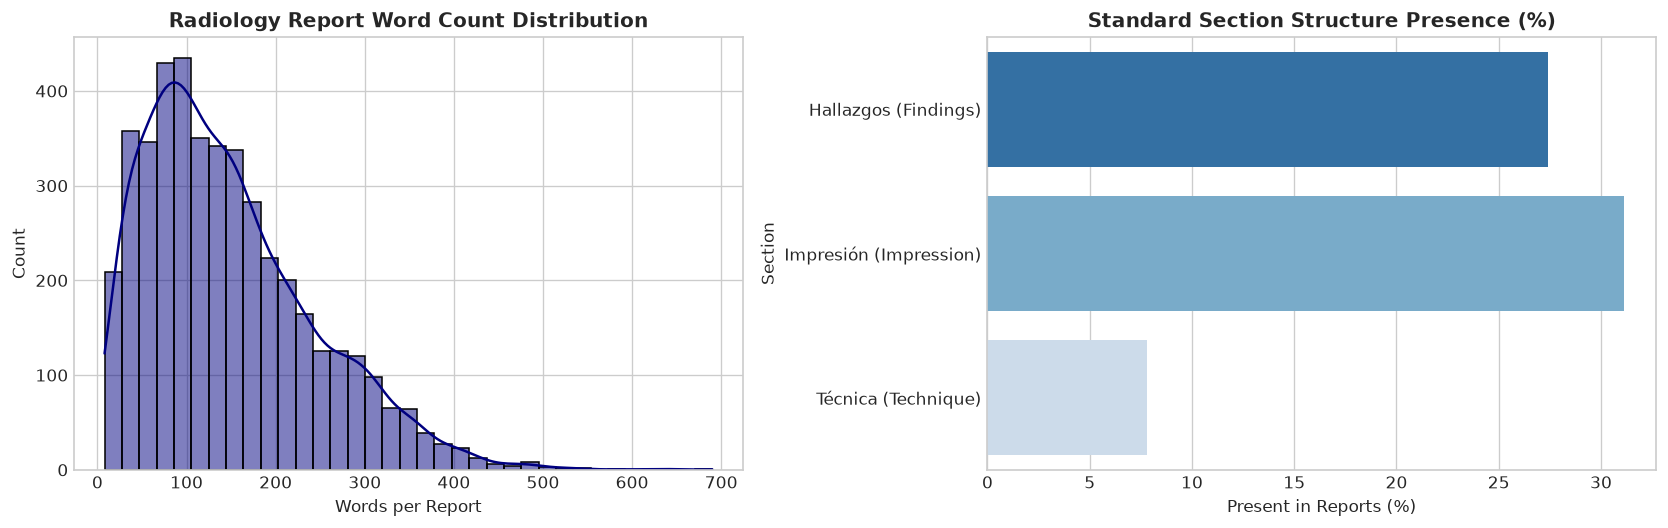

In [2]:
reports = train_df['Report'].dropna()
train_df['char_count'] = train_df['Report'].fillna('').apply(len)
train_df['word_count'] = train_df['Report'].fillna('').apply(lambda x: len(x.split()))

print(f"Total Reports: {len(reports):,}")
print(f"Word Count - Median: {train_df['word_count'].median():.0f}, Mean: {train_df['word_count'].mean():.1f}, Max: {train_df['word_count'].max()}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(train_df['word_count'], bins=35, kde=True, color='navy', ax=ax1)
ax1.set_title('Radiology Report Word Count Distribution', fontweight='bold')
ax1.set_xlabel('Words per Report')

# Top section headers
has_hallazgos = train_df['Report'].str.contains('hallazgos|findings', case=False, na=False).sum()
has_impresion = train_df['Report'].str.contains('impresión|conclusion|diagnóstico', case=False, na=False).sum()
has_tecnica = train_df['Report'].str.contains('técnica|secuencias', case=False, na=False).sum()

sections_df = pd.DataFrame({
    'Section': ['Hallazgos (Findings)', 'Impresión (Impression)', 'Técnica (Technique)'],
    'Present in Reports (%)': [has_hallazgos/len(reports)*100, has_impresion/len(reports)*100, has_tecnica/len(reports)*100]
})
sns.barplot(data=sections_df, x='Present in Reports (%)', y='Section', hue='Section', palette='Blues_r', legend=False, ax=ax2)
ax2.set_title('Standard Section Structure Presence (%)', fontweight='bold')
plt.tight_layout()
plt.show()


## 2. Spanish Medical Regex & NLP Extractor Implementation

In [3]:
def extract_weak_labels_from_report(text: str) -> dict:
    if not isinstance(text, str) or not text.strip():
        return {col: 0.0 for col in TARGET_COLUMNS}
    
    t = text.lower()
    labels = {}
    
    # 1. ACL
    acl_pos = bool(re.search(r'(rotura|desgarro|lesi[oó]n|avulsi[oó]n|interrupci[oó]n|afectaci[oó]n).*?(cruzado anterior|lca)', t) or
                  re.search(r'(lca|cruzado anterior).*?(rotura|desgarro|lesi[oó]n|avulsi[oó]n|interrumpido)', t))
    acl_neg = bool(re.search(r'(cruzado anterior|lca).*?(normal|intacto|continuo|sin alteraciones|sin signos de rotura|conservad[oa])', t) or
                  re.search(r'(no se observan|sin).*?(rotura|lesi[oó]n).*?(cruzado anterior|lca)', t))
    labels['ACL'] = 1.0 if (acl_pos and not acl_neg) else 0.0
    
    # 2. MCL
    mcl_pos = bool(re.search(r'(rotura|desgarro|lesi[oó]n|esguince|engrosamiento).*?(colateral medial|colateral interno|lcm|lci)', t))
    mcl_neg = bool(re.search(r'(colateral medial|colateral interno|lcm|lci).*?(normal|intacto|continuo|sin alteraciones|conservad[oa])', t))
    labels['MCL'] = 1.0 if (mcl_pos and not mcl_neg) else 0.0
    
    # 3. Medial Meniscus
    mm_pos = bool(re.search(r'(rotura|desgarro|lesi[oó]n|fisura|amputaci[oó]n|compleja).*?(menisco medial|menisco interno|cuerpo posterior.*?interno|cuerno posterior.*?medial)', t) or
                 re.search(r'(menisco medial|menisco interno).*?(rotura|desgarro|lesi[oó]n|fisura|amputaci[oó]n)', t))
    mm_neg = bool(re.search(r'(menisco medial|menisco interno).*?(morfolog[ií]a y se[nñ]al conservada|normal|sin alteraciones|sin signos de rotura)', t))
    labels['Medial Meniscus'] = 1.0 if (mm_pos and not mm_neg) else 0.0

    # 4. Lateral Meniscus
    lm_pos = bool(re.search(r'(rotura|desgarro|lesi[oó]n|fisura|amputaci[oó]n).*?(menisco lateral|menisco externo)', t) or
                 re.search(r'(menisco lateral|menisco externo).*?(rotura|desgarro|lesi[oó]n|fisura|amputaci[oó]n)', t))
    lm_neg = bool(re.search(r'(menisco lateral|menisco externo).*?(morfolog[ií]a y se[nñ]al conservada|normal|sin alteraciones|sin signos de rotura)', t))
    labels['Lateral Meniscus'] = 1.0 if (lm_pos and not lm_neg) else 0.0

    # 5. Medial OA
    labels['Medial OA'] = 1.0 if re.search(r'(artrosis|condropat[ií]a|desgaste|pinzamiento).*?(medial|interno|femorotibial medial|femorotibial interno)', t) else 0.0
    
    # 6. Lateral OA
    labels['Lateral OA'] = 1.0 if re.search(r'(artrosis|condropat[ií]a|desgaste|pinzamiento).*?(lateral|externo|femorotibial lateral|femorotibial externo)', t) else 0.0
    
    # 7. PF OA
    labels['PF OA'] = 1.0 if re.search(r'(artrosis|condropat[ií]a|condromalacia|desgaste).*?(femoropatelar|patelar|rotulian[oa]|tr[oó]clea)', t) else 0.0

    # 8. Effusion
    eff_pos = bool(re.search(r'(derrame|l[ií]quido intraarticular|hidrartros|abundante l[ií]quido)', t))
    eff_neg = bool(re.search(r'(sin derrame|no se observa derrame|derrame ausente|m[ií]nima cuant[ií]a fisiol[oó]gica)', t))
    labels['Effusion'] = 1.0 if (eff_pos and not eff_neg) else 0.0

    # 9. Synovitis
    labels['Synovitis'] = 1.0 if re.search(r'(sinovitis|engrosamiento sinovial|hipertrofia sinovial|plica sinovial)', t) else 0.0

    # 10. Baker's
    labels["Baker's"] = 1.0 if re.search(r'(quiste de baker|quiste popl[ií]teo|baker)', t) else 0.0

    # 11. Contusion
    labels['Contusion'] = 1.0 if re.search(r'(edema [oó]seo|contusi[oó]n [oó]sea|bruise|edema trabecular)', t) else 0.0

    # 12. Fracture
    labels['Fracture'] = 1.0 if re.search(r'(fractura|trazo de fractura|avulsi[oó]n [oó]sea|hundimiento cortical)', t) else 0.0

    return labels

print("Weak label extractor initialized.")


Weak label extractor initialized.


## 3. Benchmark Extractor vs Ground-Truth Annotations (N=58)

,Abnormality,Accuracy (%),F1-Score,True Positives (GT),Extracted Positives
0,ACL,62.1,0.154,24,2
1,MCL,87.9,0.364,9,2
2,Medial Meniscus,46.6,0.000,26,5
3,Lateral Meniscus,63.8,0.222,23,4
4,Medial OA,72.4,0.111,15,3
5,Lateral OA,82.8,0.286,11,3
6,PF OA,69.0,0.308,21,5
7,Effusion,43.1,0.233,35,8
8,Synovitis,56.9,0.194,27,4
9,Baker's,72.4,0.467,12,18


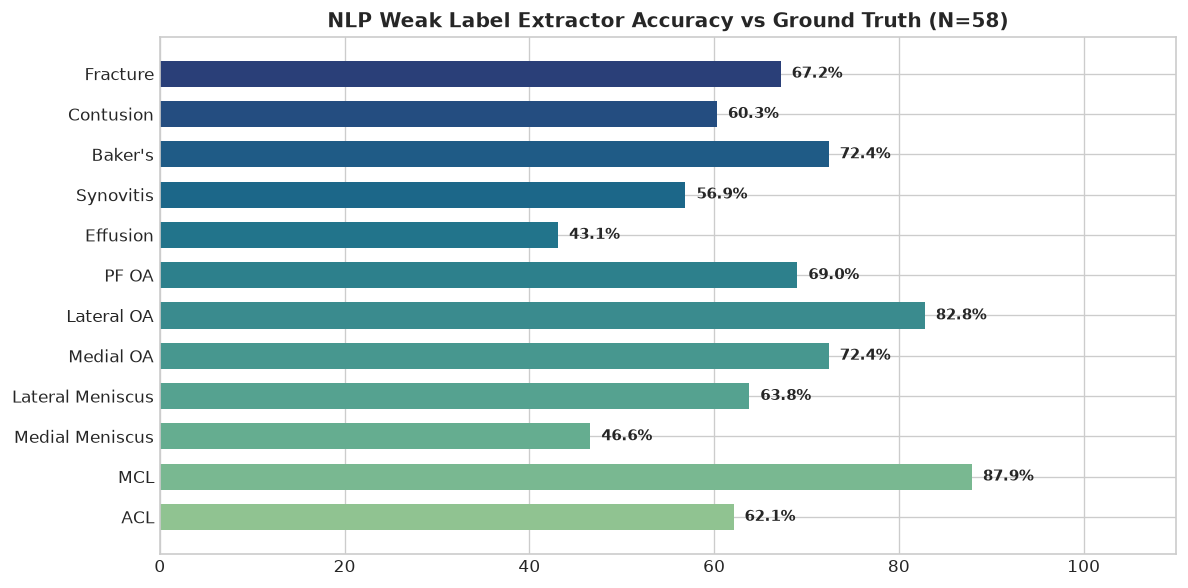

In [4]:
labeled_df = train_df[train_df[TARGET_COLUMNS].notnull().any(axis=1)].copy()

# Run extractor on labeled subset
extracted = [extract_weak_labels_from_report(r) for r in labeled_df['Report']]
df_extracted = pd.DataFrame(extracted, index=labeled_df.index)

benchmark_rows = []
for col in TARGET_COLUMNS:
    y_true = labeled_df[col].values
    y_pred = df_extracted[col].values
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    benchmark_rows.append({
        'Abnormality': col,
        'Accuracy (%)': round(acc * 100, 1),
        'F1-Score': round(f1, 3),
        'True Positives (GT)': int(y_true.sum()),
        'Extracted Positives': int(y_pred.sum())
    })

bench_df = pd.DataFrame(benchmark_rows)
display(bench_df)

fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette("crest", len(bench_df))
bars = ax.barh(bench_df['Abnormality'], bench_df['Accuracy (%)'], color=colors, height=0.65)
ax.set_title('NLP Weak Label Extractor Accuracy vs Ground Truth (N=58)', fontweight='bold')
for bar in bars:
    w = bar.get_width()
    ax.text(w + 1.2, bar.get_y() + bar.get_height() / 2, f"{w:.1f}%",
            ha='left', va='center', fontsize=9, fontweight='bold')
plt.xlim(0, 110)
plt.tight_layout()
plt.show()


## 4. Generate & Save Master Pseudo-Labels for all 4,349 Unlabeled Studies

In [5]:
# Extract pseudo-labels across the entire dataset
all_extracted = [extract_weak_labels_from_report(r) for r in train_df['Report']]
pseudo_df = pd.DataFrame(all_extracted)
pseudo_df['StudyInstanceUID'] = train_df['StudyInstanceUID']

# Overwrite with ground-truth labels where available
for col in TARGET_COLUMNS:
    pseudo_df[col] = train_df[col].combine_first(pseudo_df[col])

pseudo_df.to_csv("data/pseudo_labels_master.csv", index=False)
print("✓ Master pseudo-labels saved to data/pseudo_labels_master.csv")
print("Total positive counts in master pseudo-dataset:")
print(pseudo_df[TARGET_COLUMNS].sum())


✓ Master pseudo-labels saved to data/pseudo_labels_master.csv
Total positive counts in master pseudo-dataset:
ACL                   80.0
MCL                   69.0
Medial Meniscus      253.0
Lateral Meniscus     133.0
Medial OA            184.0
Lateral OA           120.0
PF OA                171.0
Effusion             477.0
Synovitis            137.0
Baker's             1447.0
Contusion            497.0
Fracture              82.0
dtype: float64
